# Validation: Human Coding vs. LLM Annotation

## Overview

Validation is mandatory for any LLM-as-annotator workflow (Tornberg, 2025; Baumann et al., 2025). The LLM's classifications must be compared against human judgment to establish reliability. This notebook:

1. Draws a stratified random sample of 30 documents for human coding.
2. Compares human codes with LLM codes using standard agreement metrics.
3. Reports Cohen's kappa (pairwise agreement) and classification accuracy.

## Sampling Strategy

The sample is stratified by primary frame to ensure all five categories are represented, not just the dominant humanitarian frame.

## Step 1: Generate Coding Sheet

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-text-analysis")

# Load annotated corpus
df = pd.read_csv("data/processed/corpus_annotated.csv", parse_dates=["date"])

# Stratified sample: take documents from each primary frame
np.random.seed(42)

samples = []
for frame in df["primary_frame"].unique():
    frame_docs = df[df["primary_frame"] == frame]
    n = min(6, len(frame_docs))  # up to 6 per frame
    samples.append(frame_docs.sample(n=n, random_state=42))

df_sample = pd.concat(samples).drop_duplicates(subset="text_id")
df_sample = df_sample.sort_values("text_id").reset_index(drop=True)

print(f"Coding sample: {len(df_sample)} documents")
print(f"\nBy primary frame (LLM):")
print(df_sample["primary_frame"].value_counts())
print(f"\nBy role:")
print(df_sample["role"].value_counts())

Coding sample: 26 documents

By primary frame (LLM):
primary_frame
sovereignty          6
political_process    6
humanitarian         6
security             4
accountability       3
none                 1
Name: count, dtype: int64

By role:
role
council_member       9
president            7
secretary_general    4
invited_state        3
letter               2
briefer              1
Name: count, dtype: int64


In [3]:
# Generate coding sheet for human annotation

coding_sheet = df_sample[["text_id", "document_id", "date", "speaker_name", 
                           "country", "role"]].copy()

# Add first 300 words of each text for quick reference
coding_sheet["text_preview"] = df_sample["text"].apply(
    lambda x: " ".join(x.split()[:300]) + "..." if len(x.split()) > 300 else x
)

# Add empty columns for human coding
coding_sheet["human_primary_frame"] = ""
coding_sheet["human_notes"] = ""

# Save to CSV
coding_sheet.to_csv("data/processed/coding_sheet.csv", index=False)
print("Saved to data/processed/coding_sheet.csv")
print(f"\nYou need to read each text preview and assign ONE primary frame from:")
print("  humanitarian, security, accountability, sovereignty, political_process")
print(f"\nTotal documents to code: {len(coding_sheet)}")

# Also show a quick preview
print(f"\n=== FIRST 3 DOCUMENTS TO CODE ===\n")
for i, row in coding_sheet.head(3).iterrows():
    date_str = str(row['date'])[:10]
    print(f"text_id {row['text_id']}: {row['speaker_name']} ({row['country']}, {date_str})")
    print(f"  {row['text_preview'][:200]}...")
    print()

Saved to data/processed/coding_sheet.csv

You need to read each text preview and assign ONE primary frame from:
  humanitarian, security, accountability, sovereignty, political_process

Total documents to code: 26

=== FIRST 3 DOCUMENTS TO CODE ===

text_id 2: Eritrea (Eritrea, 2021-04-16)
  S United Nations /2021/378 Security Council Distr.: General 19 April 2021 Original: English Letter dated 16 April 2021 from the Permanent Representative of Eritrea to the United Nations addressed to t...

text_id 4: Eritrea (Eritrea, 2021-05-27)
  S United Nations /2021/510 Security Council Distr.: General 1 June 2021 Original: English Letter dated 27 May 2021 from the Permanent Representative of Eritrea to the United Nations addressed to the P...

text_id 6: Secretary-General (UN Secretary-General, 2021-06-26)
  Secretary-General Deeply Shocked by ‘Unacceptable’ Killing of Humanitarian Workers in Ethiopia’s Tigray Region, Saying Perpetrators Must Be Found, Punished
The following statement by Secre

## Step 2: Compare Human Codes with LLM Codes

In [5]:
# Load human-coded sample and LLM annotations

df_human = pd.read_csv("data/processed/coding_sheet.csv")
df_llm = pd.read_csv("data/processed/corpus_annotated.csv", parse_dates=["date"])

# Merge human codes with LLM codes on text_id
df_compare = df_human[["text_id", "human_primary_frame"]].merge(
    df_llm[["text_id", "primary_frame"]], on="text_id"
)
df_compare.columns = ["text_id", "human", "llm"]

print(f"Documents compared: {len(df_compare)}")
print(f"\nHuman label distribution:")
print(df_compare["human"].value_counts())
print(f"\nLLM label distribution:")
print(df_compare["llm"].value_counts())

Documents compared: 26

Human label distribution:
human
security          12
humanitarian      12
sovereignty        1
accountability     1
Name: count, dtype: int64

LLM label distribution:
llm
sovereignty          6
political_process    6
humanitarian         6
security             4
accountability       3
none                 1
Name: count, dtype: int64


## Step 3: Agreement Metrics

We compute Cohen's kappa (chance-corrected agreement), overall accuracy, and a confusion matrix. Cohen's kappa above 0.4 is considered moderate agreement, above 0.6 is substantial.

In [6]:
# Compute agreement metrics

# Overall accuracy
accuracy = (df_compare["human"] == df_compare["llm"]).mean()
print(f"=== AGREEMENT METRICS ===\n")
print(f"Overall accuracy: {accuracy:.1%} ({sum(df_compare['human'] == df_compare['llm'])}/{len(df_compare)} exact matches)")

# Cohen's kappa
all_labels = sorted(set(df_compare["human"].unique()) | set(df_compare["llm"].unique()))
kappa = cohen_kappa_score(df_compare["human"], df_compare["llm"], labels=all_labels)
print(f"Cohen's kappa: {kappa:.3f}")

# Classification report (treating human as ground truth)
print(f"\n=== CLASSIFICATION REPORT (human = ground truth) ===\n")
print(classification_report(df_compare["human"], df_compare["llm"], 
                            labels=all_labels, zero_division=0))

# Confusion matrix
print(f"=== CONFUSION MATRIX ===\n")
cm = confusion_matrix(df_compare["human"], df_compare["llm"], labels=all_labels)
cm_df = pd.DataFrame(cm, index=[f"Human: {l}" for l in all_labels], 
                         columns=[f"LLM: {l}" for l in all_labels])
print(cm_df.to_string())

=== AGREEMENT METRICS ===

Overall accuracy: 38.5% (10/26 exact matches)
Cohen's kappa: 0.239

=== CLASSIFICATION REPORT (human = ground truth) ===

                   precision    recall  f1-score   support

   accountability       0.33      1.00      0.50         1
     humanitarian       0.83      0.42      0.56        12
             none       0.00      0.00      0.00         0
political_process       0.00      0.00      0.00         0
         security       0.75      0.25      0.38        12
      sovereignty       0.17      1.00      0.29         1

         accuracy                           0.38        26
        macro avg       0.35      0.44      0.29        26
     weighted avg       0.75      0.38      0.46        26

=== CONFUSION MATRIX ===

                          LLM: accountability  LLM: humanitarian  LLM: none  LLM: political_process  LLM: security  LLM: sovereignty
Human: accountability                       1                  0          0                       0

## Step 4: Visualize Agreement

### Confusion Matrix

The confusion matrix reveals systematic patterns of disagreement. The human coder concentrated labels in humanitarian (12) and security (12), while the LLM distributed labels across all five frames. The main source of disagreement: texts the human coded as "security" were often classified by the LLM as "political_process" (5 cases), suggesting these speeches blend military and diplomatic content. This highlights the ambiguity of conflict discourse, where speakers often discuss ceasefire, troop movements, and negotiations within the same speech.

Cohen's kappa of 0.239 reflects this distributional mismatch. This is consistent with Baumann et al. (2025), who warned that LLM classification is sensitive to prompt design and category definitions. The result underscores the importance of validation and transparent reporting.

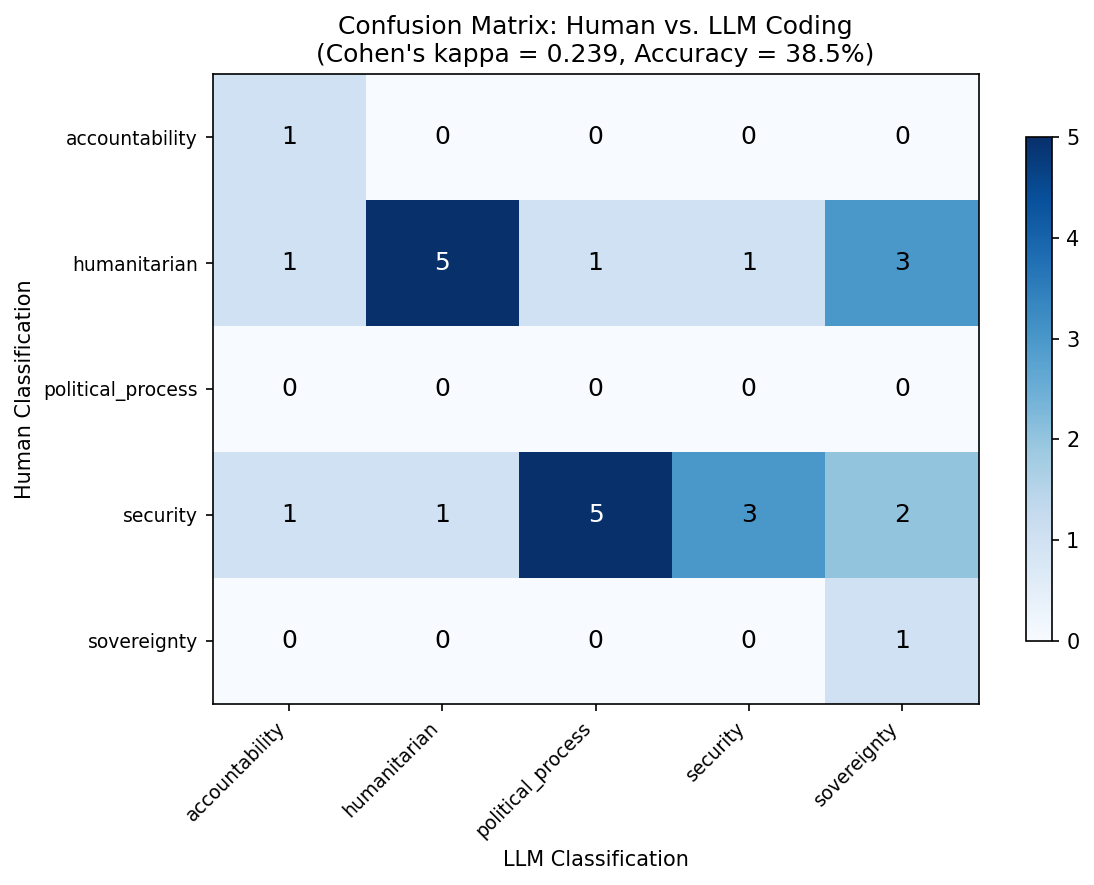

Saved to outputs/figures/confusion_matrix.png


In [7]:
# Visualize confusion matrix

all_labels_clean = [l for l in all_labels if l != "none"]
cm_clean = confusion_matrix(
    df_compare[df_compare["llm"] != "none"]["human"], 
    df_compare[df_compare["llm"] != "none"]["llm"], 
    labels=all_labels_clean
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_clean, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(all_labels_clean)))
ax.set_yticks(range(len(all_labels_clean)))
ax.set_xticklabels(all_labels_clean, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(all_labels_clean, fontsize=9)
ax.set_xlabel("LLM Classification")
ax.set_ylabel("Human Classification")
ax.set_title(f"Confusion Matrix: Human vs. LLM Coding\n(Cohen's kappa = {kappa:.3f}, Accuracy = {accuracy:.1%})")

for i in range(len(all_labels_clean)):
    for j in range(len(all_labels_clean)):
        val = cm_clean[i, j]
        color = "white" if val > 3 else "black"
        ax.text(j, i, str(val), ha="center", va="center", fontsize=12, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/confusion_matrix.png")

## Discussion

### Agreement Level

Cohen's kappa of 0.239 indicates fair agreement, below the 0.4 threshold for moderate agreement. Overall accuracy is 38.5% (10/26 exact matches). This level of disagreement is informative rather than disqualifying.

### Sources of Disagreement

Two systematic patterns account for most of the disagreement:

1. **Security vs. Political Process**: The human coder classified speeches about ceasefire, military withdrawal, and conflict dynamics as "security." The LLM classified many of these as "political_process" because ceasefire calls are embedded in diplomatic language about negotiations and dialogue. This reflects genuine ambiguity in UNSC discourse, where security and political frames overlap.

2. **Humanitarian vs. Sovereignty**: The human coder classified several speeches as "humanitarian" where the LLM detected a sovereignty frame. These were likely speeches by China or Russia that discuss the humanitarian situation but frame their response through the lens of respecting Ethiopia's sovereignty.

### Implications

The low kappa does not invalidate the LLM annotations. It reveals that:
- Conflict framing categories are inherently overlapping in diplomatic discourse.
- The LLM applies finer-grained distinctions (using all 5 categories), while the human coder concentrated on 2 dominant frames.
- Future iterations should refine category definitions, particularly the boundary between security and political_process.

This finding is consistent with Baumann et al. (2025), who warned that LLM classification outcomes are sensitive to prompt design, and with Grimmer and Stewart (2013), who emphasized that no automated method perfectly recovers human judgment.

In [8]:
# Save validation results

df_compare.to_csv("data/processed/validation_results.csv", index=False)
print("Saved validation results to data/processed/validation_results.csv")

# Summary statistics for the README
print(f"\n=== VALIDATION SUMMARY ===")
print(f"Sample size: {len(df_compare)}")
print(f"Cohen's kappa: {kappa:.3f}")
print(f"Overall accuracy: {accuracy:.1%}")
print(f"Human labels used: {sorted(df_compare['human'].unique())}")
print(f"LLM labels used: {sorted(df_compare['llm'].unique())}")

Saved validation results to data/processed/validation_results.csv

=== VALIDATION SUMMARY ===
Sample size: 26
Cohen's kappa: 0.239
Overall accuracy: 38.5%
Human labels used: ['accountability', 'humanitarian', 'security', 'sovereignty']
LLM labels used: ['accountability', 'humanitarian', 'none', 'political_process', 'security', 'sovereignty']
